# MWE 30 - DRP-443 Dilated IFN porosity and absolute permeability from RAW image

This notebook estimates porosity and absolute permeability for:

- `examples/data/drp-443/DilatedIFN.raw`

Reference values from Table 2 of:

- Song, W. et al. (2022). *Upscaling of Transport Properties in Complex
  Hydraulic Fracture Systems*. SPE Journal.
  <https://doi.org/10.2118/212849-PA>

Using the Dilated IFN row from Table 2:

- Binary image voxel size: `550 x 550 x 500`
- Resolution: `12.559 um`
- Average aperture: `117.36 um`
- Absolute permeability (left-to-right): `36.73 darcies`

Notes:

- This DRP-443 workflow intentionally runs on the **full sample**.
- No ROI/subvolume selection is applied.

## Data source and citation

Dataset source:

- Digital Porous Media Portal (DPM), DRP-443 dataset:
  <https://digitalporousmedia.org/published-datasets/drp.project.published.DRP-443>

Reference paper:

- Song, W., Prodanovic, M., Santos, J. E., Yao, J., Zhang, K., & Yang, Y. (2022).
  *Upscaling of Transport Properties in Complex Hydraulic Fracture Systems*.
  SPE Journal. <https://doi.org/10.2118/212849-PA>

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import porespy as ps

from voids.geom import characteristic_size
from voids.graph.metrics import connectivity_metrics, coordination_numbers
from voids.image import extract_spanning_pore_network, infer_sample_axes
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.physics.thermo import TabulatedWaterViscosityModel

In [2]:
# Inputs
raw_relpath = Path("drp-443") / "DilatedIFN.raw"
raw_shape = (550, 550, 500)
raw_dtype = np.uint8
raw_order = "F"  # DRP-443 RAW volumes are stored in Fortran-style voxel ordering.
raw_void_value = 0

voxel_size_um = 12.559
voxel_size_m = voxel_size_um * 1.0e-6

paper_table_reference = "Table 2"
paper_average_aperture_um = 117.36
paper_kabs_darcy = 36.73
paper_kabs_mD = 1000.0 * paper_kabs_darcy

dataset_citation = (
    "Digital Porous Media Portal. DRP-443 dataset. "
    "https://digitalporousmedia.org/published-datasets/drp.project.published.DRP-443"
)
paper_citation = (
    "Song, W., Prodanovic, M., Santos, J. E., Yao, J., Zhang, K., & Yang, Y. (2022). "
    "Upscaling of Transport Properties in Complex Hydraulic Fracture Systems. "
    "SPE Journal. https://doi.org/10.2118/212849-PA"
)

# Modeling controls
flow_axis = "x"  # Paper computes absolute permeability left-to-right.
compute_directional_all_axes = True
trim_nonpercolating_paths = True
geometry_repairs: str | None = "imperial_export"
conductance_models: tuple[str, ...] = ("valvatne_blunt",)

pressure_gradient_pa_per_m = 1.0e4
pressure_reference_pa = 5.0e6

viscosity_backend = "thermo"
viscosity_temperature_k = 298.15
viscosity_pressure_points = 192
nonlinear_solver = "newton"
nonlinear_pressure_tolerance = 1.0e-10

# Output controls
save_outputs = True

viscosity_model = TabulatedWaterViscosityModel.from_backend(
    viscosity_backend,
    temperature=viscosity_temperature_k,
    pressure_points=viscosity_pressure_points,
)

In [3]:
def raw_to_void_image(raw_image: np.ndarray, *, void_value: int) -> np.ndarray:
    """Convert raw segmented image to void=1, solid=0 convention."""
    raw_arr = np.asarray(raw_image, dtype=np.uint8)
    return (raw_arr == np.uint8(void_value)).astype(np.int8)


def prepare_axis_image(
    image: np.ndarray,
    *,
    axis: str,
    trim_nonpercolating: bool,
) -> np.ndarray:
    """Optionally trim to axis-percolating paths before extraction."""
    if not trim_nonpercolating:
        return np.asarray(image, dtype=np.int8)
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    trimmed = ps.filters.trim_nonpercolating_paths(
        np.asarray(image, dtype=bool),
        axis=axis_index,
    )
    return trimmed.astype(np.int8)

In [4]:
examples_data = data_path()
raw_path = examples_data / raw_relpath

im_full_raw = np.memmap(
    raw_path, mode="r", dtype=raw_dtype, shape=raw_shape, order=raw_order
)
im_full = raw_to_void_image(im_full_raw, void_value=raw_void_value)
phi_image_full = float(np.mean(im_full))

_, axis_lengths, axis_areas, inferred_flow_axis = infer_sample_axes(
    im_full.shape, voxel_size=voxel_size_m
)

print(f"RAW path: {raw_path}")
print(f"Shape: {raw_shape}")
print(f"dtype: {im_full_raw.dtype}")
print(f"Memory order: {raw_order}")
print(
    f"Raw unique values (central block): {np.unique(np.asarray(im_full_raw[:50, :50, :50]))}"
)
print(f"Void value convention: raw == {raw_void_value}")
print(f"Full-volume porosity: {100.0 * phi_image_full:.4f}%")
print(f"Inferred longest axis: {inferred_flow_axis}")
print(f"Flow axis used: {flow_axis}")
print(f"Axis lengths [m]: {axis_lengths}")
print(f"Axis areas [m^2]: {axis_areas}")

RAW path: E:\Work\voids\examples\data\drp-443\DilatedIFN.raw
Shape: (550, 550, 500)
dtype: uint8
Memory order: F
Raw unique values (central block): [  0 255]
Void value convention: raw == 0
Full-volume porosity: 11.2428%
Inferred longest axis: x
Flow axis used: x
Axis lengths [m]: {'x': 0.00690745, 'y': 0.00690745, 'z': 0.0062794999999999995}
Axis areas [m^2]: {'x': 4.3375332275e-05, 'y': 4.3375332275e-05, 'z': 4.77128655025e-05}


## Quick visual check of the full binary image

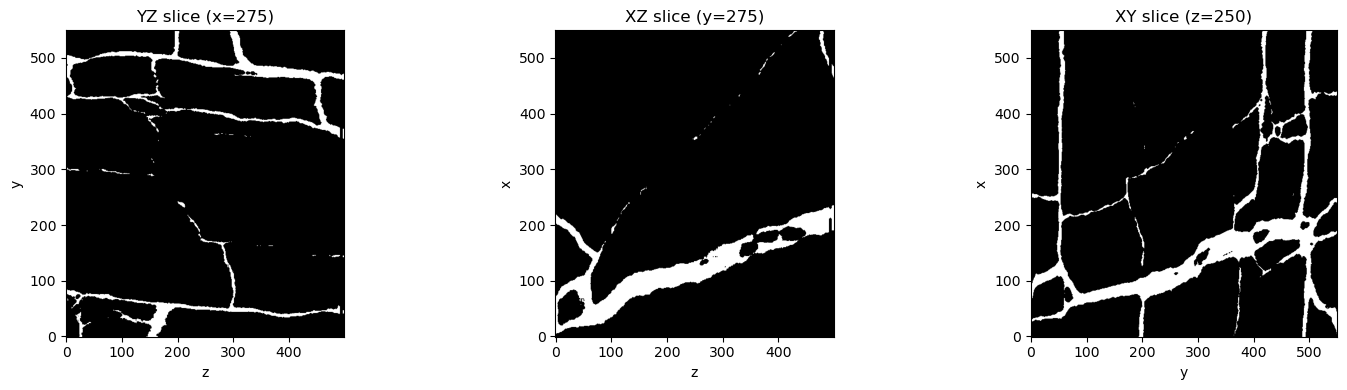

In [5]:
mid_x, mid_y, mid_z = (n // 2 for n in raw_shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(
    np.asarray(im_full[mid_x, :, :]), cmap="gray", origin="lower", vmin=0, vmax=1
)
axes[0].set_title(f"YZ slice (x={mid_x})")
axes[0].set_xlabel("z")
axes[0].set_ylabel("y")

axes[1].imshow(
    np.asarray(im_full[:, mid_y, :]), cmap="gray", origin="lower", vmin=0, vmax=1
)
axes[1].set_title(f"XZ slice (y={mid_y})")
axes[1].set_xlabel("z")
axes[1].set_ylabel("x")

axes[2].imshow(
    np.asarray(im_full[:, :, mid_z]), cmap="gray", origin="lower", vmin=0, vmax=1
)
axes[2].set_title(f"XY slice (z={mid_z})")
axes[2].set_xlabel("y")
axes[2].set_ylabel("x")

fig.tight_layout()

In [6]:
def extract_axis_network(axis: str):
    """Extract one axis-spanning network from the full sample."""
    axis_image = prepare_axis_image(
        im_full,
        axis=axis,
        trim_nonpercolating=trim_nonpercolating_paths,
    )
    extract_axis = extract_spanning_pore_network(
        axis_image,
        voxel_size=voxel_size_m,
        flow_axis=axis,
        length_unit="m",
        geometry_repairs=geometry_repairs,
        provenance_notes={
            "raw_source": str(raw_relpath).replace("\\", "/"),
            "raw_shape_voxels": raw_shape,
            "paper_table_reference": paper_table_reference,
            "paper_average_aperture_um": paper_average_aperture_um,
            "paper_kabs_darcy": paper_kabs_darcy,
            "paper_kabs_mD": paper_kabs_mD,
            "dataset_citation": dataset_citation,
            "paper_citation": paper_citation,
            "trim_nonpercolating_paths": trim_nonpercolating_paths,
            "conductance_models": list(conductance_models),
            "geometry_repairs": geometry_repairs,
            "full_sample_analysis": True,
        },
    )
    return axis_image, extract_axis


im_flow, extract = extract_axis_network(flow_axis)
net_full = extract.net_full
net = extract.net

phi_image_flow = float(np.mean(im_flow))

print(f"Backend: {extract.backend} {extract.backend_version}")
print(f"Imported full network: Np={net_full.Np}, Nt={net_full.Nt}")
print(f"Axis-spanning network ({flow_axis}): Np={net.Np}, Nt={net.Nt}")
print(f"Trim nonpercolating paths: {trim_nonpercolating_paths}")
print(
    f"Viscosity model: {viscosity_model.backend_name} at "
    f"{viscosity_model.temperature:.2f} K"
)
print(
    f"Full-volume porosity after {flow_axis}-path trim: "
    f"{100.0 * phi_image_flow:.4f}%"
)

Backend: porespy 3.0.4
Imported full network: Np=10489, Nt=27831
Axis-spanning network (x): Np=10489, Nt=27831
Trim nonpercolating paths: True
Viscosity model: thermo at 298.15 K
Full-volume porosity after x-path trim: 11.2176%


In [7]:
phi_abs = absolute_porosity(net)
phi_eff = effective_porosity(net, axis=flow_axis)


def solve_axis_with_fallback(net_axis, axis: str):
    """Solve one axis using the configured conductance models."""
    delta_p = pressure_gradient_pa_per_m * axis_lengths[axis]
    bc_axis = PressureBC(
        f"inlet_{axis}min",
        f"outlet_{axis}max",
        pin=pressure_reference_pa + delta_p,
        pout=pressure_reference_pa,
    )
    last_exc: Exception | None = None
    for model in conductance_models:
        try:
            res_axis = solve(
                net_axis,
                fluid=FluidSinglePhase(viscosity_model=viscosity_model),
                bc=bc_axis,
                axis=axis,
                options=SinglePhaseOptions(
                    conductance_model=model,
                    solver="direct",
                    nonlinear_solver=nonlinear_solver,
                    nonlinear_pressure_tolerance=nonlinear_pressure_tolerance,
                ),
            )
            return res_axis, model
        except Exception as exc:
            last_exc = exc
    raise RuntimeError(
        f"Single-phase solve failed for all conductance models on axis '{axis}'"
    ) from last_exc


res, used_conductance_model = solve_axis_with_fallback(net, flow_axis)

M2_PER_MD = 9.869233e-16
k_flow_m2 = float(res.permeability[flow_axis])
k_flow_mD = k_flow_m2 / M2_PER_MD

axes_available = tuple(ax for ax in ("x", "y", "z") if ax in axis_lengths)
if not compute_directional_all_axes:
    axes_available = (flow_axis,)

directional_records: list[dict[str, float | str]] = []
for ax in axes_available:
    if ax == flow_axis:
        net_ax = net
        res_ax = res
        model_ax = used_conductance_model
    else:
        _, extract_ax = extract_axis_network(ax)
        net_ax = extract_ax.net
        res_ax, model_ax = solve_axis_with_fallback(net_ax, ax)

    k_ax_m2 = float(res_ax.permeability[ax])
    k_ax_mD = k_ax_m2 / M2_PER_MD
    directional_records.append(
        {
            "axis": ax,
            "k_m2": k_ax_m2,
            "k_mD": k_ax_mD,
            "n_pores": float(net_ax.Np),
            "n_throats": float(net_ax.Nt),
            "conductance_model": str(model_ax),
        }
    )

kabs_directional = (
    pd.DataFrame(directional_records).sort_values("axis").reset_index(drop=True)
)

kabs_mean_mD = float(kabs_directional["k_mD"].mean())
kabs_rms_mD = float(
    np.sqrt(np.mean(np.square(kabs_directional["k_mD"].to_numpy(dtype=float))))
)

k_flow_abs_error_mD = k_flow_mD - paper_kabs_mD
k_flow_rel_error_pct = 100.0 * k_flow_abs_error_mD / paper_kabs_mD

estimated_properties = pd.DataFrame(
    [
        {
            "property": "Porosity (image full volume)",
            "estimated": 100.0 * phi_image_full,
            "units": "%",
            "paper_reference": np.nan,
            "abs_error": np.nan,
            "rel_error_pct": np.nan,
            "reference_label": "SPE 212849-PA Table 2",
        },
        {
            "property": "Porosity (network absolute)",
            "estimated": 100.0 * phi_abs,
            "units": "%",
            "paper_reference": np.nan,
            "abs_error": np.nan,
            "rel_error_pct": np.nan,
            "reference_label": "SPE 212849-PA Table 2",
        },
        {
            "property": "Porosity (network effective)",
            "estimated": 100.0 * phi_eff,
            "units": "%",
            "paper_reference": np.nan,
            "abs_error": np.nan,
            "rel_error_pct": np.nan,
            "reference_label": "SPE 212849-PA Table 2",
        },
        {
            "property": f"Absolute permeability K{flow_axis} (paper flow direction)",
            "estimated": k_flow_mD,
            "units": "mD",
            "paper_reference": paper_kabs_mD,
            "abs_error": k_flow_abs_error_mD,
            "rel_error_pct": k_flow_rel_error_pct,
            "reference_label": "SPE 212849-PA Table 2",
        },
        {
            "property": "Paper average aperture",
            "estimated": np.nan,
            "units": "um",
            "paper_reference": paper_average_aperture_um,
            "abs_error": np.nan,
            "rel_error_pct": np.nan,
            "reference_label": "SPE 212849-PA Table 2",
        },
    ]
)

print(f"Conductance model used: {used_conductance_model}")
print(
    f"Reference viscosity used for permeability reporting: "
    f"{res.reference_viscosity:.6e} Pa s"
)
print(
    f"Nonlinear iterations ({nonlinear_solver}): "
    f"{res.solver_info.get('nonlinear_iterations', 'n/a')}"
)
print(f"Total flow rate Q: {res.total_flow_rate:.6e} m^3/s")
print(f"K{flow_axis}: {k_flow_m2:.6e} m^2 ({k_flow_mD:.3f} mD)")
print(f"Mass-balance error: {res.mass_balance_error:.3e}")
print()
print("Directional Kabs estimates [mD]:")
print(kabs_directional[["axis", "k_mD", "n_pores", "n_throats", "conductance_model"]])
print(f"Arithmetic mean Kabs across computed axes: {kabs_mean_mD:.3f} mD")
print(f"Quadratic mean Kabs across computed axes: {kabs_rms_mD:.3f} mD")
print(
    f"Paper reference Kabs (flow direction): {paper_kabs_mD:.2f} mD, "
    f"relative error: {k_flow_rel_error_pct:.2f}%"
)
estimated_properties

Conductance model used: valvatne_blunt
Reference viscosity used for permeability reporting: 8.893800e-04 Pa s
Nonlinear iterations (newton): 1
Total flow rate Q: 1.022703e-08 m^3/s
Kx: 2.096979e-11 m^2 (21247.639 mD)
Mass-balance error: 1.907e-16

Directional Kabs estimates [mD]:
  axis           k_mD  n_pores  n_throats conductance_model
0    x   21247.638887  10489.0    27831.0    valvatne_blunt
1    y   44509.970026  10489.0    27831.0    valvatne_blunt
2    z  115811.459080  10489.0    27831.0    valvatne_blunt
Arithmetic mean Kabs across computed axes: 60523.023 mD
Quadratic mean Kabs across computed axes: 72674.832 mD
Paper reference Kabs (flow direction): 36730.00 mD, relative error: -42.15%


,property,estimated,units,paper_reference,abs_error,rel_error_pct,reference_label
0,Porosity (image full volume),11.242819,%,NaN,NaN,NaN,SPE 212849-PA Table 2
1,Porosity (network absolute),11.421615,%,NaN,NaN,NaN,SPE 212849-PA Table 2
2,Porosity (network effective),11.421615,%,NaN,NaN,NaN,SPE 212849-PA Table 2
3,Absolute permeability Kx (paper flow direction),21247.638887,mD,36730.00,-15482.361113,-42.151814,SPE 212849-PA Table 2
4,Paper average aperture,NaN,um,117.36,NaN,NaN,SPE 212849-PA Table 2


## Kabs comparison (mD)

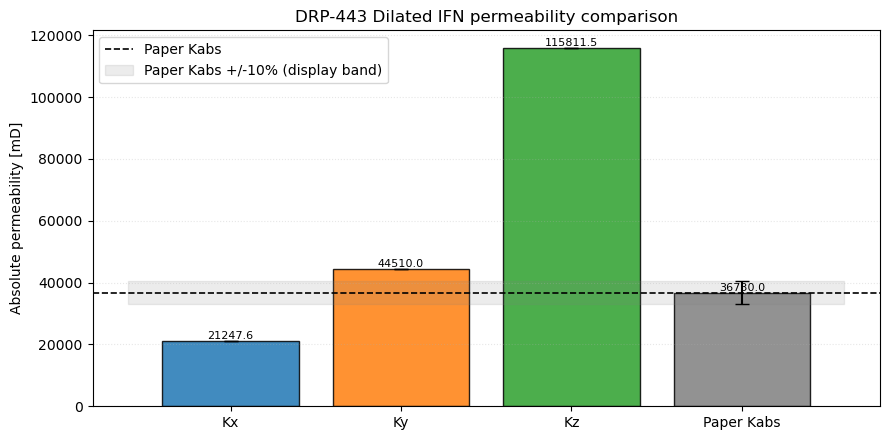

In [8]:
paper_kabs_error_mD = (
    0.10 * paper_kabs_mD
)  # +/-10% assumed uncertainty band for display only

bar_labels = [f"K{ax}" for ax in kabs_directional["axis"]] + ["Paper Kabs"]
bar_values = list(kabs_directional["k_mD"].to_numpy(dtype=float)) + [paper_kabs_mD]
bar_errors = [0.0] * (len(bar_labels) - 1) + [paper_kabs_error_mD]

fig_k, ax_k = plt.subplots(figsize=(9, 4.5))
bars = ax_k.bar(
    bar_labels,
    bar_values,
    yerr=bar_errors,
    capsize=5,
    color=["tab:blue", "tab:orange", "tab:green", "tab:gray"][: len(bar_labels)],
    edgecolor="black",
    alpha=0.85,
)
ax_k.axhline(
    paper_kabs_mD, color="black", linestyle="--", linewidth=1.2, label="Paper Kabs"
)
ax_k.fill_between(
    [-0.6, len(bar_labels) - 0.4],
    paper_kabs_mD - paper_kabs_error_mD,
    paper_kabs_mD + paper_kabs_error_mD,
    color="gray",
    alpha=0.15,
    label="Paper Kabs +/-10% (display band)",
)
ax_k.set_ylabel("Absolute permeability [mD]")
ax_k.set_title("DRP-443 Dilated IFN permeability comparison")
ax_k.grid(alpha=0.3, linestyle=":", axis="y")
ax_k.legend()

for rect, val in zip(bars, bar_values):
    ax_k.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height(),
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig_k.tight_layout()

## Pore-network statistics

In [9]:
pore_size_m, pore_size_field = characteristic_size(net.pore, expected_shape=(net.Np,))
throat_size_m, throat_size_field = characteristic_size(
    net.throat, expected_shape=(net.Nt,)
)

pore_size_um = 1.0e6 * pore_size_m
throat_size_um = 1.0e6 * throat_size_m

coord = coordination_numbers(net)
coord_vals, coord_counts = np.unique(coord, return_counts=True)

pore_volume = np.asarray(net.pore.get("region_volume", net.pore["volume"]), dtype=float)
order = np.argsort(pore_size_um)
cum_pore_volume = np.cumsum(pore_volume[order]) / pore_volume.sum()

conn = connectivity_metrics(net)

network_stats = pd.DataFrame(
    [
        {"metric": "Np", "value": float(net.Np), "units": "count"},
        {"metric": "Nt", "value": float(net.Nt), "units": "count"},
        {"metric": "Mean coordination", "value": float(np.mean(coord)), "units": "-"},
        {"metric": "Max coordination", "value": float(np.max(coord)), "units": "-"},
        {
            "metric": f"Mean pore size ({pore_size_field})",
            "value": float(np.mean(pore_size_um)),
            "units": "um",
        },
        {
            "metric": f"Median pore size ({pore_size_field})",
            "value": float(np.median(pore_size_um)),
            "units": "um",
        },
        {
            "metric": f"Mean throat size ({throat_size_field})",
            "value": float(np.mean(throat_size_um)),
            "units": "um",
        },
        {
            "metric": f"Median throat size ({throat_size_field})",
            "value": float(np.median(throat_size_um)),
            "units": "um",
        },
        {
            "metric": "Connected components",
            "value": float(conn.n_components),
            "units": "count",
        },
        {
            "metric": "Giant component fraction",
            "value": float(conn.giant_component_fraction),
            "units": "-",
        },
        {
            "metric": "Dead-end pore fraction",
            "value": float(conn.dead_end_fraction),
            "units": "-",
        },
    ]
)

network_stats

,metric,value,units
0,Np,10489.000000,count
1,Nt,27831.000000,count
2,Mean coordination,5.306702,-
3,Max coordination,32.000000,-
4,Mean pore size (diameter_equivalent),138.608914,um
5,Median pore size (diameter_equivalent),119.670816,um
6,Mean throat size (diameter_equivalent),91.467020,um
7,Median throat size (diameter_equivalent),74.987545,um
8,Connected components,1.000000,count
9,Giant component fraction,1.000000,-


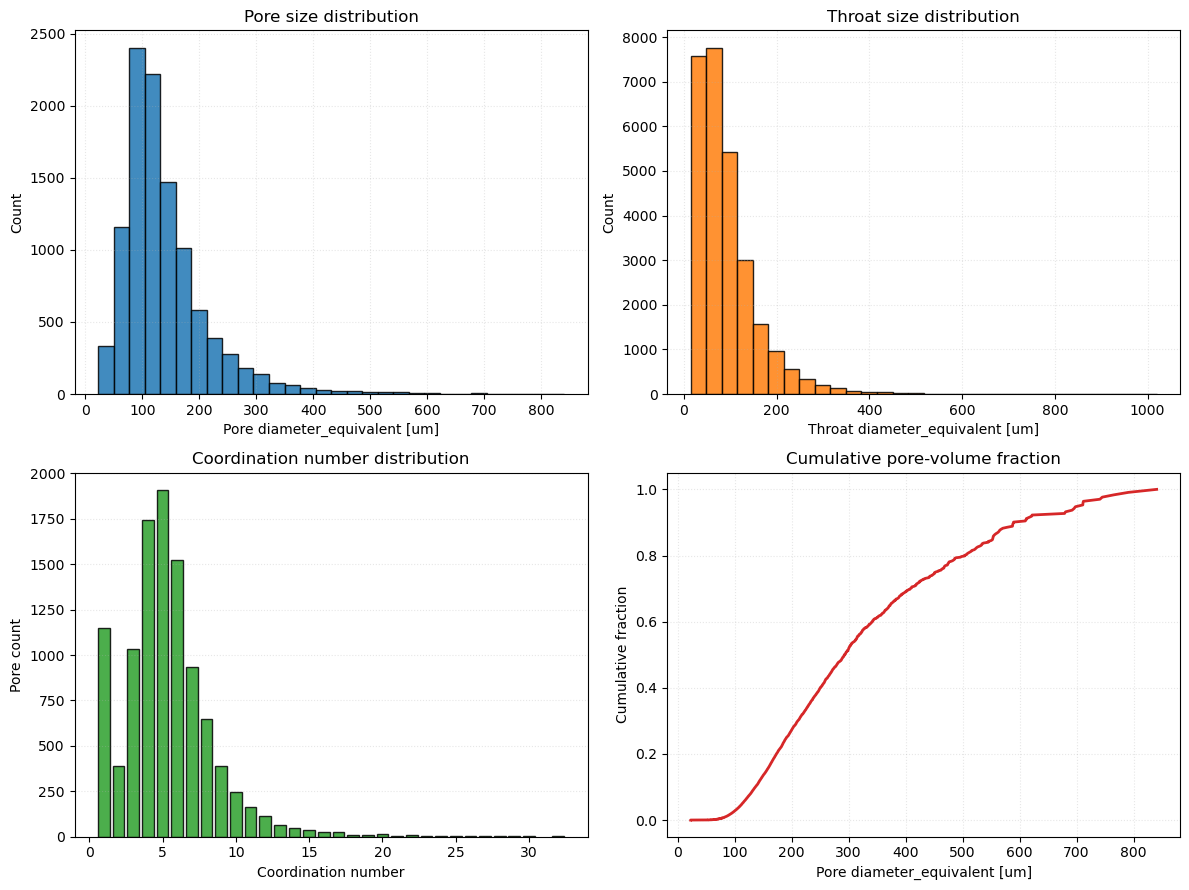

In [10]:
fig_s, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(pore_size_um, bins=30, color="tab:blue", alpha=0.85, edgecolor="black")
axes[0, 0].set_title("Pore size distribution")
axes[0, 0].set_xlabel(f"Pore {pore_size_field} [um]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3, linestyle=":")

axes[0, 1].hist(
    throat_size_um,
    bins=30,
    color="tab:orange",
    alpha=0.85,
    edgecolor="black",
)
axes[0, 1].set_title("Throat size distribution")
axes[0, 1].set_xlabel(f"Throat {throat_size_field} [um]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3, linestyle=":")

axes[1, 0].bar(
    coord_vals,
    coord_counts,
    color="tab:green",
    alpha=0.85,
    edgecolor="black",
)
axes[1, 0].set_title("Coordination number distribution")
axes[1, 0].set_xlabel("Coordination number")
axes[1, 0].set_ylabel("Pore count")
axes[1, 0].grid(alpha=0.3, linestyle=":", axis="y")

axes[1, 1].plot(pore_size_um[order], cum_pore_volume, color="tab:red", linewidth=2)
axes[1, 1].set_title("Cumulative pore-volume fraction")
axes[1, 1].set_xlabel(f"Pore {pore_size_field} [um]")
axes[1, 1].set_ylabel("Cumulative fraction")
axes[1, 1].grid(alpha=0.3, linestyle=":")

fig_s.tight_layout()

## Save outputs

In [11]:
out_dir = examples_data / "drp-443"
out_net_full_h5 = out_dir / "DilatedIFN_network_full_voids.h5"
out_net_span_h5 = out_dir / f"DilatedIFN_network_{flow_axis}spanning_voids.h5"
out_props_csv = out_dir / "DilatedIFN_estimated_properties.csv"
out_stats_csv = out_dir / "DilatedIFN_network_stats.csv"
out_kabs_dir_csv = out_dir / "DilatedIFN_kabs_directional.csv"
out_kabs_png = out_dir / "DilatedIFN_kabs_comparison.png"
out_stats_png = out_dir / "DilatedIFN_network_stats.png"
out_slices_png = out_dir / "DilatedIFN_slices.png"

if save_outputs:
    save_hdf5(net_full, out_net_full_h5)
    save_hdf5(net, out_net_span_h5)
    estimated_properties.to_csv(out_props_csv, index=False)
    network_stats.to_csv(out_stats_csv, index=False)
    kabs_directional.to_csv(out_kabs_dir_csv, index=False)
    fig_k.savefig(out_kabs_png, dpi=180)
    fig_s.savefig(out_stats_png, dpi=180)
    fig.savefig(out_slices_png, dpi=180)

print(f"Saved full network: {out_net_full_h5}")
print(f"Saved spanning network: {out_net_span_h5}")
print(f"Saved estimated properties: {out_props_csv}")
print(f"Saved network stats: {out_stats_csv}")
print(f"Saved directional Kabs: {out_kabs_dir_csv}")
print(f"Saved Kabs plot: {out_kabs_png}")
print(f"Saved stats plot: {out_stats_png}")
print(f"Saved slice plot: {out_slices_png}")

Saved full network: E:\Work\voids\examples\data\drp-443\DilatedIFN_network_full_voids.h5
Saved spanning network: E:\Work\voids\examples\data\drp-443\DilatedIFN_network_xspanning_voids.h5
Saved estimated properties: E:\Work\voids\examples\data\drp-443\DilatedIFN_estimated_properties.csv
Saved network stats: E:\Work\voids\examples\data\drp-443\DilatedIFN_network_stats.csv
Saved directional Kabs: E:\Work\voids\examples\data\drp-443\DilatedIFN_kabs_directional.csv
Saved Kabs plot: E:\Work\voids\examples\data\drp-443\DilatedIFN_kabs_comparison.png
Saved stats plot: E:\Work\voids\examples\data\drp-443\DilatedIFN_network_stats.png
Saved slice plot: E:\Work\voids\examples\data\drp-443\DilatedIFN_slices.png


In [12]:
plt.close("all")